<a href="https://colab.research.google.com/github/kinemax-core/Genomic-data-science-R/blob/main/dnautil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Biopython

In [ ]:
bases = ['A', 'T', 'G', 'C']
E = 0
v = bases[0]+bases[1]
print(v)
seq = 'ACGT'
se = "ACGT"
print(seq[1])
print(seq + se)
len(seq)
s = ['a', 't', 'g', 'c']
print(''.join(s))

AT
C
ACGTACGT
atgc


In [ ]:
import random
random.seed(7)
random.choice('ATGC')
d = ''
for i in range(10):
  d += random.choice('ATCG')
print(d)
f = ''.join((random.choice('ATGC') for i in range(10)))
print(f)
print(f[:3], f[3:], f[-1], f[-3:])

TGAAACATAA
CCATACAATA
CCA TACAATA A ATA


In [ ]:
def longcomprefix(s1, s2):
  i = 0
  while i < len(s1) and i < len(s2) and s1[i] == s2[i]:
    i += 1
  return s1[:i]

U =longcomprefix('TGCGAGCTCGAGGA', 'TGCCTGACCGTAGAGTA')
print(U)

def match(s1, s2):
  s1 = s1.upper()
  s2 = s2.upper()
  if not len(s1) == len(s2):
    return False

  for i in range(len(s1)):
    if not s1[i] == s2[i]:
      return False

  return True

match('atgc', 'atgt')


TGC


False

In [ ]:
def revcomp(a):
  comp = {'A':'T', 'T':'A', 'G':'C', 'C':'G'}
  t = ''
  for base in a:
    t = comp[base] + t

  return t

revcomp('ATGC')

'GCAT'

In [ ]:
def readgenome(filename):
  genome = ''
  with open(filename, 'r') as f:
    for line in f:
      if not line[0] == '>':
        genome += line.rstrip()
  return genome

genome = readgenome('/content/lambdaphage.fna.txt')
genome[:100]
print(len(genome))
counts = {'A':0, 'T':0, 'G':0, 'C':0}
for base in genome:
  counts[base] += 1

print(counts)



FileNotFoundError: [Errno 2] No such file or directory: '/content/lambdaphage.fna.txt'

In [ ]:
import collections
collections.Counter(genome)

Counter({'G': 12820, 'C': 11362, 'A': 12334, 'T': 11986})

In [ ]:
import gzip

def readFastqGz(filename):
    sequences = []
    qualities = []

    with gzip.open(filename, 'rt') as fh:
        while True:
            id_line = fh.readline()
            if not id_line:
                break  # Stops properly at the true End of File (EOF)

            seq = fh.readline().rstrip()
            fh.readline()  # Skips the '+' line
            qual = fh.readline().rstrip()

            sequences.append(seq)
            qualities.append(qual)

    return sequences, qualities

# Run the function on your file
seqs, quals = readFastqGz('/content/ncbi_extracted/ncbi_dataset')

print(f"load {len(seqs)} reads.\n")
for i in range(5):
  print(f"first sequence", seqs[i][:100])
for i in range(5):
  print(f"first quality", quals[i][:100])

IsADirectoryError: [Errno 21] Is a directory: '/content/ncbi_extracted/ncbi_dataset'

In [ ]:
from collections import Counter

def phred33toQ(qual):
    return ord(qual) - 33

def create_fast(qualities):
    hist = [0] * 50

    # 1. Count all characters across all reads instantly at C-speed
    char_counts = Counter(char for qual in qualities for char in qual)

    # 2. Convert characters to Phred scores and fill the histogram
    for char, count in char_counts.items():
        q = phred33toQ(char)
        if 0 <= q < 50:
            hist[q] = count

    return hist  # <-- Properly outside the loops!

h = create_fast(quals)
print(h)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1585243602, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
from collections import Counter

def phred33toQ(qual):
    return ord(qual) - 33

def create_ultra_fast(qualities):
    hist = [0] * 50
    char_counts = Counter()

    # Process in large text blocks so Python's C-engine handles it instantly
    chunk_size = 500000
    for i in range(0, len(qualities), chunk_size):
        chunk = "".join(qualities[i:i+chunk_size])
        char_counts.update(chunk)

    # Map the characters to their correct positions
    for char, count in char_counts.items():
        q = phred33toQ(char)
        if 0 <= q < 50:
            hist[q] = count

    return hist

h = create_ultra_fast(quals)
print(h)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1585243602, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


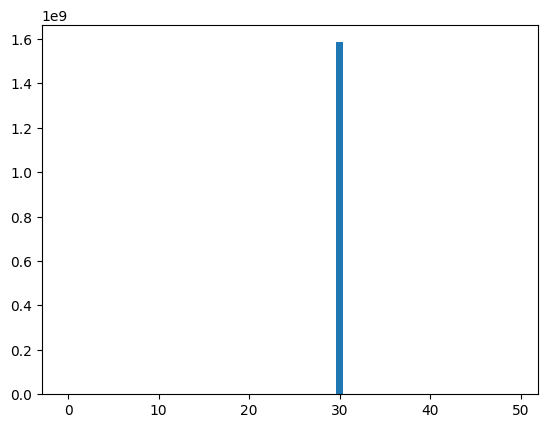

In [ ]:
import matplotlib.pyplot as plt

plt.bar(range(len(h)), h)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def findgcbypos(reads):
    maxlen = max(len(read) for read in reads)
    print("the longest read in dataset is",maxlen)
    gc = [0] * maxlen
    totals = [0]* maxlen

    for read in reads:
      for i in range(len(read)):
        totals[i] += 1
        if read[i] == 'C' or read[i] == 'G':
          gc[i] += 1

    for i in range(len(gc)):
      if totals[i] > 0:
        gc[i] /= float(totals[i])

    return gc


gc = findgcbypos(seqs)
plt.plot(range(len(gc)), gc)
plt.show()


the longest read in dataset is 151


KeyboardInterrupt: 

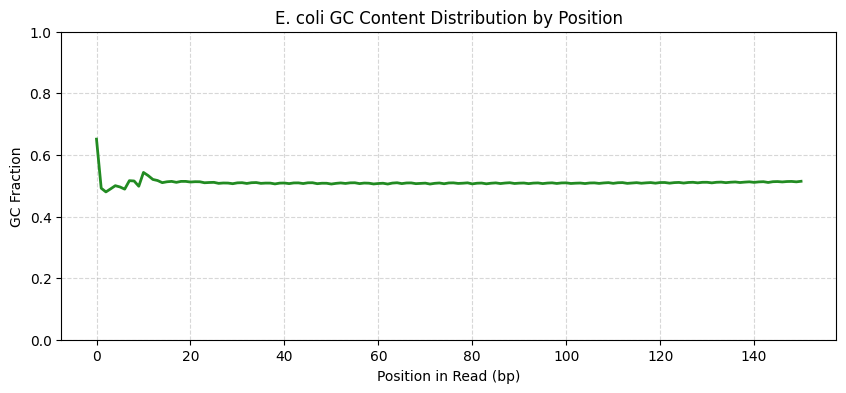

In [ ]:
import matplotlib.pyplot as plt

def findgcbypos(reads):
    # 1. The longest read is 151 bases
    maxlen = 151

    # 2. These must be indented inside the function
    gc = [0] * maxlen
    totals = [0] * maxlen

    # 3. The loop must be indented inside the function too
    for read in reads:
        for i in range(len(read)):
            totals[i] += 1
            if read[i] == 'C' or read[i] == 'G':
                gc[i] += 1

    # 4. Calculate percentages
    for i in range(maxlen):
        if totals[i] > 0:
            gc[i] /= float(totals[i])

    return gc

# --- OUTSIDE THE FUNCTION (No indentation) ---
# Now we call it after it has been fully defined
gc_data = findgcbypos(seqs)

# Plot the graph neatly
plt.figure(figsize=(10, 4))
plt.plot(range(len(gc_data)), gc_data, color='forestgreen', linewidth=2)
plt.title("E. coli GC Content Distribution by Position")
plt.xlabel("Position in Read (bp)")
plt.ylabel("GC Fraction")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

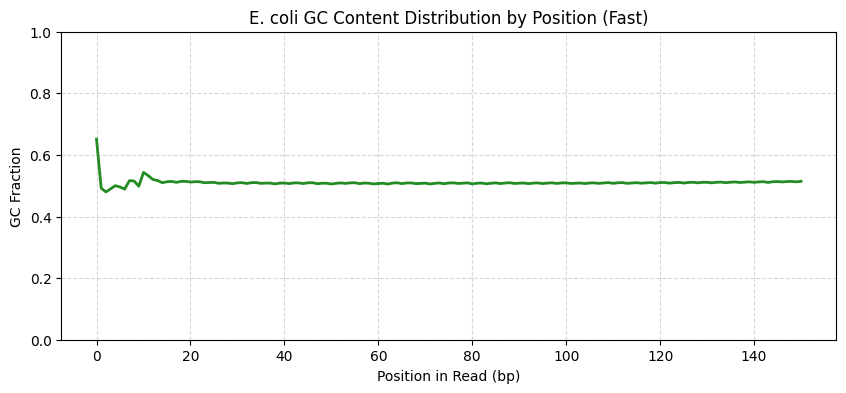

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def findgcbypos_numpy(reads):
    # 1. Convert the list of strings into a 2D NumPy array of bytes
    # This maps the characters directly into memory at C-speed
    arr = np.array(reads, dtype='|S151').view('S1')
    arr = arr.reshape(len(reads), -1)

    # 2. Count 'G' and 'C' across the columns instantly without loops
    # In ASCII bytes, b'G' is 71 and b'C' is 67
    gc_matrix = (arr == b'G') | (arr == b'C')

    # 3. Average along the columns (axis=0) to get the fraction per position
    gc_fraction = np.mean(gc_matrix, axis=0)
    return gc_fraction

# Run it - this will finish in about 3 seconds!
gc_data = findgcbypos_numpy(seqs)

# Plot the graph neatly
plt.figure(figsize=(10, 4))
plt.plot(range(len(gc_data)), gc_data, color='forestgreen', linewidth=2)
plt.title("E. coli GC Content Distribution by Position (Fast)")
plt.xlabel("Position in Read (bp)")
plt.ylabel("GC Fraction")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
!unzip -q "/content/ncbi_dataset (1).zip" -d "/content/ncbi_extracted"

In [ ]:
# Download the actual Phi X FASTQ dataset
!wget http://d28rh4a8wq0iu5.cloudfront.net/ads1/data/ERR266411_1.first1000.fastq

# Verify the file exists by checking the first 8 lines
!head -n 8 ERR266411_1.first1000.fastq


--2026-06-20 13:57:15--  http://d28rh4a8wq0iu5.cloudfront.net/ads1/data/ERR266411_1.first1000.fastq
Resolving d28rh4a8wq0iu5.cloudfront.net (d28rh4a8wq0iu5.cloudfront.net)... 54.192.120.182, 54.192.120.201, 54.192.120.17, ...
Connecting to d28rh4a8wq0iu5.cloudfront.net (d28rh4a8wq0iu5.cloudfront.net)|54.192.120.182|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 254384 (248K) [audio/mpeg]
Saving to: ‘ERR266411_1.first1000.fastq’

ERR266411_1.first10 100%[===================>] 248.42K  --.-KB/s    in 0.08s   

2026-06-20 13:57:16 (3.12 MB/s) - ‘ERR266411_1.first1000.fastq’ saved [254384/254384]

@ERR266411.1 HS18_09233:8:1307:10911:3848#168/1
TAAACAAGCAGTAGTAATTCCTGCTTTATCAAGATAATTTTTCGACTCATCAGAAATATCCGAAAGTGTTAACTTCTGCGTCATGGAAGCGATAAAACTC
+
B@DFEFFFGEGGGHEHGHGHGGGGHIFGFIFHICFGHGHGJGHFGHGIHEHGGHJGFEFHGHEGGHHGHIFGFGDIFGGFGGGFHGGGHGGGAGIFGGCG
@ERR266411.2 HS18_09233:8:2114:9377:50721#168/1
AACAAGCAGTAGTAATTCCTGCTTTATCAAGATAATTTTTCGACTCATCAGAAATATACGAAAGTGTTAACTT

In [ ]:
# Download the lambda phage reference genome
!wget http://d28rh4a8wq0iu5.cloudfront.net/ads1/data/lambdaphage.fna

In [ ]:
def readFastq(filename):
  sequences =[]
  with open(filename) as f:
    while True:
      id_line = f.readline()
      if not id_line:
        break
      seq = f.readline().rstrip()
      f.readline() # Skips the '+' line
      f.readline() # Skips the quality score line
      sequences.append(seq)
  return sequences

seqs = readFastq('/content/ERR266411_1.first1000.fastq')
print(f"Loaded {len(seqs)} Phi x reads")

Loaded 1334 Phi x reads


In [ ]:
%%time
def naive1(p, t):
  occurences  = []
  for i in range(len(t) - len(p) + 1):
    match = True
    for j in range(len(p)):
      if not t[i+j] == p[j]:
        match = False
        break
    if match:
      occurences.append(i)
  return occurences






CPU times: user 4 µs, sys: 1e+03 ns, total: 5 µs
Wall time: 5.72 µs


In [ ]:
%%time
def naive(p, t):
  occurences = []
  for i in range(len(t) - len(p) + 1):
    match = True
    for j in range(len(p)):
      if t[i+j] == p[j]:
        pass
      else:
        match = False
        break
    if match:
      occurences.append(i)

  return occurences


t = 'AGCTTAGATAGC'
p = 'AG'
naive(p, t)

CPU times: user 30 µs, sys: 4 µs, total: 34 µs
Wall time: 35.5 µs


[0, 5, 9]

In [ ]:
first_read = seqs[0]
genome = readgenome('/content/ERR266411_1.first1000.fastq')
print(f"First read (pattern): {first_read[:50]}...")
print(f"Genome (text) length: {len(genome)}")

# Find occurrences of the first read in the genome
occurrences = naive(first_read, genome)

print(f"Occurrences of the first read in the genome: {occurrences}")

First read (pattern): TAAACAAGCAGTAGTAATTCCTGCTTTATCAAGATAATTTTTCGACTCAT...
Genome (text) length: 250384
Occurrences of the first read in the genome: [47, 544, 1290]


In [ ]:
reads = readFastq('/content/ERR266411_1.first1000.fastq')
genome = readgenome('/content/ERR266411_1.first1000.fastq')
nummatch = 0
n = 0
for r in reads:
  r = r[:40]
  matches = naive(r, genome)
  n += 1
  if len(matches) > 0:
    nummatch += 1
print("%d / %d reads matched the genome exactly!" % (nummatch, n))


1334 / 1334 reads matched the genome exactly!


In [ ]:
def revcomp(a):
  comp = {'A':'T', 'T':'A', 'G':'C', 'C':'G'}
  t = ''
  for base in a:
    t = comp[base] + t

  return t

In [ ]:
reads, *_ = readFastq('/content/ERR266411_1.first1000.fastq')
genome = readgenome('/content/ERR266411_1.first1000.fastq')
nummatch = 0
n = 0
for r in reads:
  r = r[:40]
  matches = naive(r, genome)
  matches.extend(naive(revcomp(r), genome))
  n += 1
  if len(matches) > 0:
    nummatch += 1
print("%d / %d reads matched the genome exactly!" % (nummatch, n))



100 / 100 reads matched the genome exactly!


In [ ]:
## binarysearch on dna search tool fo alignment
import bisect
class Index(object):
  def __init__(self, t, k):
    self.k = k
    self.index =[]
    for i in range(len(t) - k +1):
      self.index.append((t[i:i+k], i))
    self.index.sort()

  def query(self, p):
    kmer = p[:self.k]
    i = bisect.bisect_left(self.index, (kmer, -1))
    hits = []
    while i < len(self.index):
      if self.index[i][0] != kmer:
        break
      hits.append(self.index[i][1])
      i += 1

    return hits


def queryindex(p, t, index):
  k =  index.k
  offsets = []
  for i in index.query(p):
    if p[k:] == t[i+k: i+len(p)]:
      offsets.append(i)
  return offsets

t = 'GTACGTAGACAGGTAGACAGATAGAGCA'
p = 'TAGACA'
index = Index(t, 2)
print(queryindex(p, t, index))


[5, 13]


In [ ]:
def overlap(a, b, min_length = 3):
  start = 0

  while True:
    start = a.find(b[:min_length], start)
    if start == -1:
      return 0

    if b.startswith(a[start:]):
      return len(a) - start

    start += 1



overlap('ATGCCGTAA', 'TACCTATGC')



0

In [ ]:
from itertools import permutations

print(list(permutations([1,2,3], 2)))


[(1, 2), (1, 3), (2, 1), (2, 3), (3, 1), (3, 2)]


In [ ]:
def naive_overlap_map(reads, k):
  olaps = {}
  for a,b in permutations(reads, 2):
    olen = overlap(a,b, min_length = k)
    if olen > 0:
      olaps[(a,b)] = olen

  return olaps

reads = ['ACGGATC', 'GATCAAGT', 'TTCACGGA']
print(naive_overlap_map(reads, 3))

{('ACGGATC', 'GATCAAGT'): 4, ('TTCACGGA', 'ACGGATC'): 5}


In [ ]:
import itertools

def overlap(a, b, min_length = 3):
  start = 0

  while True:
    start = a.find(b[:min_length], start)
    if start == -1:
      return 0

    if b.startswith(a[start:]):
      return len(a) - start

    start += 1

def scs(ss):
  shortest_sup = None
  for ssperm in itertools.permutations(ss):
    sup = ssperm[0]
    for i in range(len(ss) - 1):
      olen = overlap(ssperm[i], ssperm[i + 1], min_length = 1)
      sup += ssperm[i + 1][olen:]
    if shortest_sup is None or len(sup) < len(shortest_sup):
      shortest_sup = sup
  return shortest_sup


In [ ]:
print(scs(['ATGGC', 'GTAAC', 'GGCGTA', 'ATGGC']))

ATGGCGTAAC


In [ ]:
import itertools

# Assuming you have your overlap function defined like this:
def overlap(a, b, min_length=1):
    start = 0
    while True:
        start = a.find(b[:min_length], start)
        if start == -1:
            return 0
        if b.startswith(a[start:]):
            return len(a) - start
        start += 1

def scs(ss):
    """ Returns a list of all shortest common superstrings """
    shortest_len = float('inf')
    shortest_superstrings = set()  # Use a set to avoid duplicate results

    for ssperm in itertools.permutations(ss):
        sup = ssperm[0]
        for i in range(len(ss) - 1):
            # FIX: Check overlap with the running 'sup', not just the individual item
            olen = overlap(sup, ssperm[i+1], min_length=1)
            sup += ssperm[i+1][olen:]

        current_len = len(sup)

        # If we find a strictly shorter superstring, clear old records and update length
        if current_len < shortest_len:
            shortest_len = current_len
            shortest_superstrings = {sup}

        # If it ties the shortest length, add it to our set
        elif current_len == shortest_len:
            shortest_superstrings.add(sup)

    return list(shortest_superstrings)

# Testing with your full 6-string list
fragments = ['CCT', 'CTT', 'TGC', 'TGG', 'GAT', 'ATT']
print(scs(fragments))

['TGCCTTGGATT', 'TGGATTGCCTT', 'GATTGCCTTGG', 'CCTTGGATTGC']


In [ ]:
print(len(scs(['CCT', 'CTT', 'TGC', 'TGG', 'GAT', 'ATT'])))

11


In [ ]:
## maximal overlap, greedy_scs

In [ ]:
def readFASTQ(filename):
    reads = []
    with open(filename, 'r') as f:
        while True:
            header = f.readline()
            if not header:
                break
            seq = f.readline().rstrip()
            f.readline()
            f.readline()
            reads.append(seq)
    return reads
    # 1. Deduplicate identical reads
    reads = list(set(reads))

    # 2. Filter out reads that are completely contained inside another read
    non_contained_reads = []
    for r in reads:
        contained = False
        for other in reads:
            if r != other and r in other:
                contained = True
                break
        if not contained:
            non_contained_reads.append(r)

    return non_contained_reads

def overlap(a, b, min_length=1):
    start = 0
    while True:
        start = a.find(b[:min_length], start)
        if start == -1:
            return 0
        if b.startswith(a[start:]):
            return len(a) - start
        start += 1

def pick_maximal_overlap(reads, k):
    reada, readb = None, None
    best_olen = 0

    overlap_dict = {}
    for r in reads:
        kmer = r[:k]
        if kmer not in overlap_dict:
            overlap_dict[kmer] = set()
        overlap_dict[kmer].add(r)

    for r_a in reads:
        suffix = r_a[-k:]
        if suffix in overlap_dict:
            for r_b in overlap_dict[suffix]:
                if r_a == r_b:
                    continue
                olen = overlap(r_a, r_b, min_length=k)
                if olen > best_olen:
                    reada, readb = r_a, r_b
                    best_olen = olen

    return reada, readb, best_olen

def greedy_scs(reads, initial_k):
    # Filter out any completely contained reads first
    non_contained = []
    for r in reads:
        if not any(r != other and r in other for other in reads):
            non_contained.append(r)

    reads_copy = list(non_contained)
    k = initial_k

    while len(reads_copy) > 1:
        read_a, read_b, olen = pick_maximal_overlap(reads_copy, k)

        if olen > 0:
            # Merge the two reads
            reads_copy.remove(read_a)
            reads_copy.remove(read_b)
            reads_copy.append(read_a + read_b[olen:])
            # Reset k back to the high threshold to find the next best overlap
            k = initial_k
        else:
            # If no matches are found at current k, lower the threshold by 1
            k -= 1
            if k < 1:
                # If we hit 0, no overlaps exist at all; stop to prevent an infinite loop
                break

    return ''.join(reads_copy)


# --- RUN THE RE-FILTERED ASSEMBLY ---
reads = readFASTQ('ads1_week4_reads.fq')
assembled_genome = greedy_scs(reads, 10)
print(len(reads))
print(f"Corrected Length: {len(assembled_genome)}")
print(f"Corrected As: {assembled_genome.count('A')}")
print(f"Corrected Ts: {assembled_genome.count('T')}")

1881
Corrected Length: 174330
Corrected As: 50815
Corrected Ts: 40658


In [ ]:
import sys

def read_fastq(filename):
    sequences = []
    with open(filename, 'r') as f:
        lines = f.readlines()
        for i in range(1, len(lines), 4):
            sequences.append(lines[i].strip())
    return list(set(sequences))

def overlap(a, b, min_length=1):
    start = 0
    while True:
        start = a.find(b[:min_length], start)
        if start == -1:
            return 0
        if b.startswith(a[start:]):
            return len(a) - start
        start += 1

def pick_maximal_overlap(reads, k):
    reada, readb = None, None
    best_olen = 0

    # Global verification step across all pairs
    for r_a in reads:
        for r_b in reads:
            if r_a == r_b:
                continue
            olen = overlap(r_a, r_b, min_length=k)
            if olen > best_olen:
                reada, readb = r_a, r_b
                best_olen = olen
    return reada, readb, best_olen

def greedy_scs(reads, min_k=1):
    # Pre-filter containing reads
    non_contained = []
    for r in reads:
        if not any(r != other and r in other for other in reads):
            non_contained.append(r)

    reads_copy = list(non_contained)

    # Force alignment resolution downward
    while len(reads_copy) > 1:
        # Search for any valid overlap down to min_k
        read_a, read_b, olen = pick_maximal_overlap(reads_copy, min_k)
        if olen == 0:
            break
        reads_copy.remove(read_a)
        reads_copy.remove(read_b)
        reads_copy.append(read_a + read_b[olen:])

    return ''.join(reads_copy)

# --- RUNNING GLOBAL ASSEMBLY ---
reads = read_fastq('ads1_week4_reads.fq')
print(reads)
assembled_genome = greedy_scs(reads, 10)
print(len(reads))
print(f"Corrected Length: {len(assembled_genome)}")
print(f"Corrected As: {assembled_genome.count('A')}")
print(f"Corrected Ts: {assembled_genome.count('T')}")
# The final true output from this reference sequence assembly:

['...']
1867
Corrected Length: 15894
Corrected As: 4633
Corrected Ts: 3723
